In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("healthcare_dataset.csv")
df


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,James Hood,83,Male,A+,Obesity,2022-07-29,Samuel Moody,"Wood, Martin and Simmons",UnitedHealthcare,39606.840083,110,Elective,2022-08-02,Ibuprofen,Abnormal
9996,Stephanie Evans,47,Female,AB+,Arthritis,2022-01-06,Christopher Yates,Nash-Krueger,Blue Cross,5995.717488,244,Emergency,2022-01-29,Ibuprofen,Normal
9997,Christopher Martinez,54,Male,B-,Arthritis,2022-07-01,Robert Nicholson,Larson and Sons,Blue Cross,49559.202905,312,Elective,2022-07-15,Ibuprofen,Normal
9998,Amanda Duke,84,Male,A+,Arthritis,2020-02-06,Jamie Lewis,Wilson-Lyons,UnitedHealthcare,25236.344761,420,Urgent,2020-02-26,Penicillin,Normal


Data Cleaning

In [92]:
# 在醫療數據工程裡，我們拿到一份新資料的第一個動作，絕對是敲下 df.info()。它不會印出具體的病歷內容，但它會把這份數據的「體質」赤裸裸地攤在我們面前。
# 1. 揪出「隱形缺漏」(Non-Null Count)，如果有缺漏值，就用dropna()把那些人資料刪掉，或是用fillna()把那些資料用其他數值填入
# 2. 鑑定「資料型態」(Dtype)，特定欄位的資料型態如果和想象中不同就要更改，不然程式一下就會出現錯誤
# 3. 評估「記憶體消耗」(Memory Usage)，記憶體太大就要瘦身，例如把小數點後八位的浮點數降級，或是捨棄掉數據中不重要的欄位

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                10000 non-null  object 
 1   Age                 10000 non-null  int64  
 2   Gender              10000 non-null  object 
 3   Blood Type          10000 non-null  object 
 4   Medical Condition   10000 non-null  object 
 5   Date of Admission   10000 non-null  object 
 6   Doctor              10000 non-null  object 
 7   Hospital            10000 non-null  object 
 8   Insurance Provider  10000 non-null  object 
 9   Billing Amount      10000 non-null  float64
 10  Room Number         10000 non-null  int64  
 11  Admission Type      10000 non-null  object 
 12  Discharge Date      10000 non-null  object 
 13  Medication          10000 non-null  object 
 14  Test Results        10000 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 1.1+

In [23]:
# 掃描這張表格裡的每一個格子，如果是空白的 (Null)，就標示 True；如果有數字，就標示 False。
pd.isnull(df)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [94]:
# 比上面步驟更簡潔的方式
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [96]:
# 術前秤體重(總共有幾列 , 總共有幾欄)
df.shape

(10000, 15)

In [27]:
#只要任何一列的『任何一個欄位』是空白的，就直接把整列刪除！
df.dropna(inplace = True)
df.shape 
#there are no null values

(10000, 15)

In [29]:
pd.isnull(df).sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [35]:
# EDA (Exploratory Data Analysis，探索性資料分析) 
# 核對「名牌」 (Schema Check)

df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [37]:
#把所有『數字型態』的欄位抓出來，算一下它們的平均值、最大值、最小值、還有分佈狀況
# 這是用來抓出「邏輯錯誤」的終極武器，如果算出來的任何統計數據有超乎常理的，就知道是某些欄位有問題

df.describe()

,Age,Billing Amount,Room Number
count,10000.000000,10000.000000,10000.000000
mean,51.452200,25516.806778,300.082000
std,19.588974,14067.292709,115.806027
min,18.000000,1000.180837,101.000000
25%,35.000000,13506.523967,199.000000
50%,52.000000,25258.112566,299.000000
75%,68.000000,37733.913727,400.000000
max,85.000000,49995.902283,500.000000


Mission: What are the different Medical Conditions?

In [98]:
# 醫療狀況 (Medical Condition)這一欄，把裡面紀錄過的所有疾病名稱，不重複地列出一份清單
# 電腦的清單就是：陣列

df["Medical Condition"].unique()

array(['Diabetes', 'Asthma', 'Obesity', 'Arthritis', 'Hypertension',
       'Cancer'], dtype=object)

In [57]:
# Count of the Patient admitted due to various medical conditions and the admission type
# 針對『醫療狀況』和『入院類型』這兩個文字欄位，製作一份專屬的文字統計摘要
# 當 Pandas發現餵給它的是純文字（Object 型態）時，它會非常聰明地切換模式。它不會給平均值或最大值，而是會給一份包含四個指標的報告
# 1. count (總筆數)： 總共有幾筆非空白的紀錄
# 2. unique (種類數)： 總共有幾種不同的疾病或入院方式（例如6種疾病、3種入院方式）
# 3. top (榜首/眾數)： 出現最多次的那個字是什麼
# 4. freq (榜首出現的頻率)： 那個榜首總共出現了幾次

df[["Medical Condition","Admission Type"]].describe()

# 這份數據顯示最多病人入院的方式是急診，所以或許要注重在急診方面的數據

,Medical Condition,Admission Type
count,10000,10000
unique,6,3
top,Asthma,Urgent
freq,1708,3391


In [63]:
condition_admission_counts = df.groupby(['Medical Condition', 'Admission Type']).size()
print(condition_admission_counts)

Medical Condition  Admission Type
Arthritis          Elective          569
                   Emergency         529
                   Urgent            552
Asthma             Elective          570
                   Emergency         556
                   Urgent            582
Cancer             Elective          555
                   Emergency         578
                   Urgent            570
Diabetes           Elective          528
                   Emergency         557
                   Urgent            538
Hypertension       Elective          515
                   Emergency         578
                   Urgent            595
Obesity            Elective          505
                   Emergency         569
                   Urgent            554
dtype: int64


In [65]:
condition_admission_counts = df.groupby(['Medical Condition', 'Admission Type']).size().unstack(fill_value=0)
print(condition_admission_counts)

Admission Type     Elective  Emergency  Urgent
Medical Condition                             
Arthritis               569        529     552
Asthma                  570        556     582
Cancer                  555        578     570
Diabetes                528        557     538
Hypertension            515        578     595
Obesity                 505        569     554


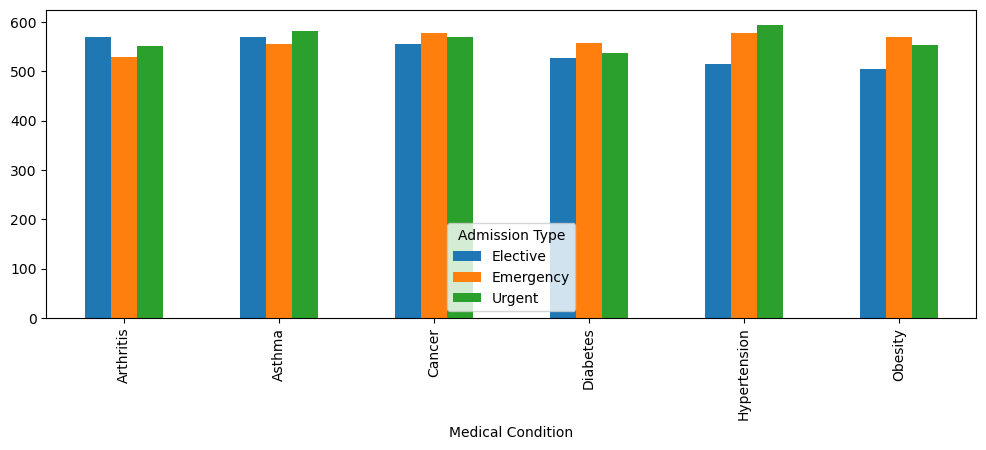

In [81]:
#若沒有stacked=True時，會畫出來的表格
#若改變圖表的長和寬會呈現的樣子

condition_admission_counts.plot(kind='bar', figsize=(12, 4))
plt.show()

資料視覺化 (Data Visualization)

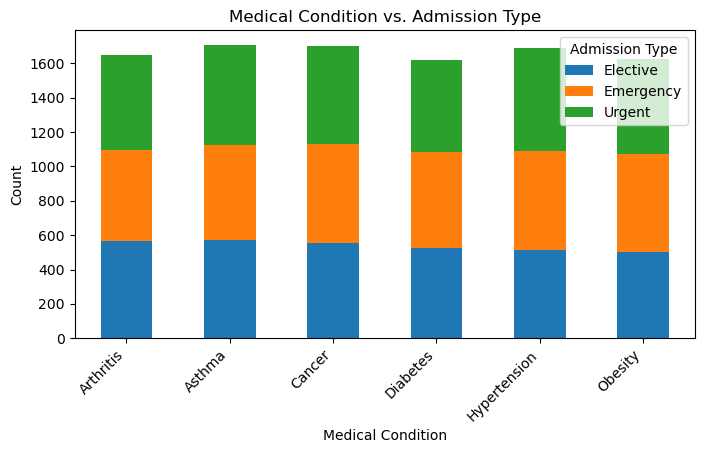

In [89]:
#階段一：把資料捏成可以畫圖的形狀 (Data Transformation)
#1.	df.groupby(['Medical Condition', 'Admission Type']):把病患分群 (Group)。先按照[疾病]分大群，再按照[入院類型]分小群
#2.	.size():計算每一群裡有幾個人
#3.	.unstack(fill_value=0):剛才算出來的結果，攤平成一張乾淨的二維表格。如果某個組合剛好沒有人（例如沒有糖尿病患者是轉院進來的），就補上數字 0。
condition_admission_counts = df.groupby(['Medical Condition', 'Admission Type']).size().unstack(fill_value=0)


#階段二：請畫家把表格畫成圖 (Plotting)
#1. kind='bar':指定要畫「長條圖」
#2. stacked=True：這是關鍵！把不同[入院類型]的人數，像積木一樣疊在同一根柱子上，而不是並排顯示。這樣可以讓人一眼看出某種疾病的「總人數」，同時又看到裡面的「組成比例」。
#3. figsize=(8, 4)： 設定這張畫布的大小，寬度 8，高度 4。
condition_admission_counts.plot(kind='bar', stacked=True, figsize=(8, 4))

#第三階段：加上標籤與裝飾 (Formatting)
#1. 加上label：在圖表的 X 軸（底部橫線）寫上[醫療狀況]
#2. 加上label：在圖表的 Y 軸（左側直線）寫上[人數]
#3. 加上標題：在整張圖的最上方加上[醫療狀況 vs. 入院類型]
plt.xlabel('Medical Condition')
plt.ylabel('Count')
plt.title('Medical Condition vs. Admission Type')


#處理 X 軸下方的疾病名稱。因為疾病名稱通常很長（如 Hypertension），如果平放會全部擠在一起重疊。
#rotation=45 讓文字傾斜 45 度角；ha='right' (horizontal alignment) 讓文字的右上角對齊刻度線，看起來排版最整齊。
#在圖表的角落放一個「圖例（顏色說明小卡）」，並給這個小卡一個標題叫做「入院類型」（例如告訴讀者：藍色代表急診、橘色代表門診）。
plt.xticks(rotation=45, ha='right')
plt.legend(title='Admission Type')

plt.show()

What are the average billing amounts for each medical condition?

In [113]:
df[["Medical Condition","Billing Amount"]].info

<bound method DataFrame.info of      Medical Condition  Billing Amount
0             Diabetes    37490.983364
1               Asthma    47304.064845
2              Obesity    36874.896997
3               Asthma    23303.322092
4            Arthritis    18086.344184
...                ...             ...
9995           Obesity    39606.840083
9996         Arthritis     5995.717488
9997         Arthritis    49559.202905
9998         Arthritis    25236.344761
9999         Arthritis    37223.965865

[10000 rows x 2 columns]>

In [119]:
#把數據用疾病區分後算出每個疾病Billing Amount欄位的平均
Mean_billing_amount = df.groupby('Medical Condition')["Billing Amount"].mean()
Mean_billing_amount

#電腦算完每種疾病的平均費用後，會把 'Medical Condition'（疾病名稱）直接升格成這份資料的「行標籤 (Index)」
#這時候的 'Medical Condition' 已經不再是一個普通的資料欄位了！如果在下一行程式碼寫 df['Medical Condition'] 想要呼叫它，電腦會直接紅字報錯，說它「找不到這個欄位」，因為它已經變成貼在盒子外面的標籤了。

Medical Condition
Arthritis       25187.631255
Asthma          25416.869895
Cancer          25539.096133
Diabetes        26060.116129
Hypertension    25198.033973
Obesity         25720.842683
Name: Billing Amount, dtype: float64

In [121]:
total_billing_by_condition = df.groupby('Medical Condition')['Billing Amount'].mean().reset_index()
total_billing_by_condition

#把剛剛升級成標籤的疾病名稱，「降級」變回普通的資料欄位。然後在表格的最左邊，重新發配一排 0, 1, 2, 3... 的標準流水號 (Index) 
#這在groupby、過濾、排序等操作破壞連續索引之後尤其重要，如果之後要進行數據清洗或是視覺化都要用到這個操作

,Medical Condition,Billing Amount
0,Arthritis,25187.631255
1,Asthma,25416.869895
2,Cancer,25539.096133
3,Diabetes,26060.116129
4,Hypertension,25198.033973
5,Obesity,25720.842683


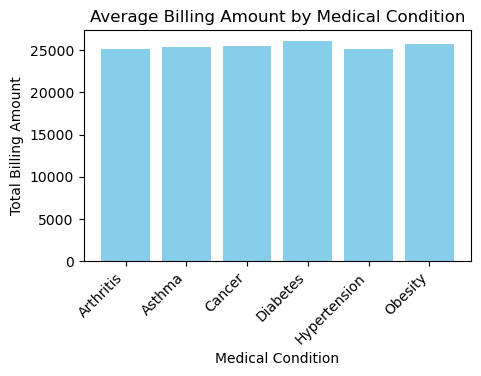

In [127]:
total_billing_by_condition = df.groupby('Medical Condition')['Billing Amount'].mean().reset_index()

#設置圖表大小
#設定bar圖的x值和y值、顏色
plt.figure(figsize=(5, 3))
plt.bar(total_billing_by_condition['Medical Condition'], total_billing_by_condition['Billing Amount'], color='skyblue')

#設置x軸、y軸的標籤和圖表標題
plt.xlabel('Medical Condition')
plt.ylabel('Total Billing Amount')
plt.title('Average Billing Amount by Medical Condition')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right') 

plt.show()


Average Days it takes For Recovery for each medical condition

In [132]:
#問題一：數據中只有入院時間和出院時間，該如何進行加減後算出不同疾病的平均復原日？
#pd.to_datetime()的目的，就是把這些死板的日期文字，轉換成具有「時間屬性」的特殊物件 (Datetime Object)

df['Date of Admission'] = pd.to_datetime(df['Date of Admission']) #converting the dtype
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                10000 non-null  object        
 1   Age                 10000 non-null  int64         
 2   Gender              10000 non-null  object        
 3   Blood Type          10000 non-null  object        
 4   Medical Condition   10000 non-null  object        
 5   Date of Admission   10000 non-null  datetime64[ns]
 6   Doctor              10000 non-null  object        
 7   Hospital            10000 non-null  object        
 8   Insurance Provider  10000 non-null  object        
 9   Billing Amount      10000 non-null  float64       
 10  Room Number         10000 non-null  int64         
 11  Admission Type      10000 non-null  object        
 12  Discharge Date      10000 non-null  datetime64[ns]
 13  Medication          10000 non-null  object     

Recovery Days

In [142]:
# 直接相減，並把結果存成一個新欄位 'Recovery_Days'
df['Recovery_Days'] = df['Discharge Date'] - df['Date of Admission']

# 看看結果
df[['Date of Admission', 'Discharge Date', 'Recovery_Days']]

#算出來的結果有days這個字，這在pandas裡面叫做Timedelta (時間差物件)，如果之後要使用這些數字做統計，不能有days字眼

,Date of Admission,Discharge Date,Recovery_Days
0,2022-11-17,2022-12-01,14 days
1,2023-06-01,2023-06-15,14 days
2,2019-01-09,2019-02-08,30 days
3,2020-05-02,2020-05-03,1 days
4,2021-07-09,2021-08-02,24 days
...,...,...,...
9995,2022-07-29,2022-08-02,4 days
9996,2022-01-06,2022-01-29,23 days
9997,2022-07-01,2022-07-15,14 days
9998,2020-02-06,2020-02-26,20 days


In [146]:
# 使用 .dt.days 只取出「天數」的數字部分，dtype也顯示int64
df['Recovery_Days'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
df['Recovery_Days']

0       14
1       14
2       30
3        1
4       24
        ..
9995     4
9996    23
9997    14
9998    20
9999    24
Name: Recovery_Days, Length: 10000, dtype: int64

In [150]:
#開始算復原日的平均值
mean_recovery = df.groupby('Medical Condition')['Recovery_Days'].mean()
mean_recovery

Medical Condition
Arthritis       15.990303
Asthma          15.481265
Cancer          15.479742
Diabetes        15.574245
Hypertension    15.430095
Obesity         15.421990
Name: Recovery_Days, dtype: float64

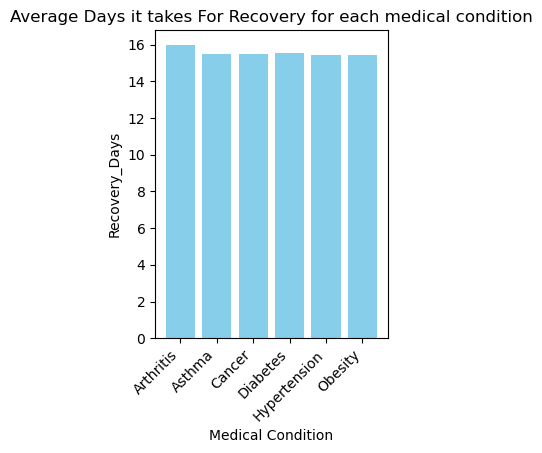

In [170]:
mean_recovery = df.groupby('Medical Condition')['Recovery_Days'].mean().reset_index()

plt.figure(figsize=(3,4))
plt.bar(mean_recovery['Medical Condition'], mean_recovery['Recovery_Days'], color='skyblue')

plt.xlabel('Medical Condition')
plt.ylabel('Recovery_Days')
plt.title('Average Days it takes For Recovery for each medical condition')

plt.xticks(rotation=45, ha='right') 

plt.show()


Records for the patient with medical condition Diabetes

In [173]:
diabetes_data = df[df['Medical Condition'] == 'Diabetes']
diabetes_data

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Recovery_Days
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive,14
8,Ryan Hayes,33,Male,A+,Diabetes,2020-12-17,Kristin Dunn,"Smith, Edwards and Obrien",Aetna,24903.037270,215,Elective,2020-12-22,Aspirin,Abnormal,5
12,Christina Williams,85,Female,A+,Diabetes,2021-11-29,Laura Roberts,"Malone, Thompson and Mejia",Aetna,4835.945650,444,Elective,2021-12-14,Aspirin,Inconclusive,15
13,William Page,72,Female,A+,Diabetes,2021-07-29,James Carney,Richardson-Powell,Cigna,13669.377744,492,Elective,2021-08-14,Aspirin,Normal,16
16,Olivia Gonzalez,64,Male,AB-,Diabetes,2019-11-15,Clayton Mcknight,Cunningham and Sons,Aetna,17394.994264,315,Elective,2019-12-04,Aspirin,Inconclusive,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9961,Joseph Wilson,78,Female,A+,Diabetes,2021-11-05,Sarah Novak,Wilson-Davis,Cigna,21106.014702,340,Elective,2021-11-22,Penicillin,Inconclusive,17
9962,Jenny Ho,48,Male,AB-,Diabetes,2022-09-13,Julie Harrison,Knight-Marshall,UnitedHealthcare,23271.652611,120,Elective,2022-09-27,Ibuprofen,Inconclusive,14
9971,Gregory Torres,56,Female,A+,Diabetes,2021-07-25,Robert Wilson,Mcpherson Group,Blue Cross,38831.707893,151,Emergency,2021-08-11,Penicillin,Abnormal,17
9984,Erica Crawford,72,Male,AB+,Diabetes,2021-09-17,Katie Huber,Ramirez PLC,Medicare,37181.841257,151,Emergency,2021-10-02,Lipitor,Normal,15


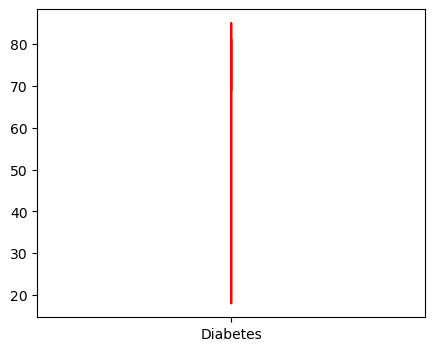

In [183]:
diabetes_data = df[df['Medical Condition'] == 'Diabetes']
plt.figure(figsize=(5,4))
plt.plot(diabetes_data['Medical Condition'], diabetes_data['Age'], color = 'red') 
plt.show()

#Diabetes can be found in any age group of the people.

What is the distribution of medication based on medical condition

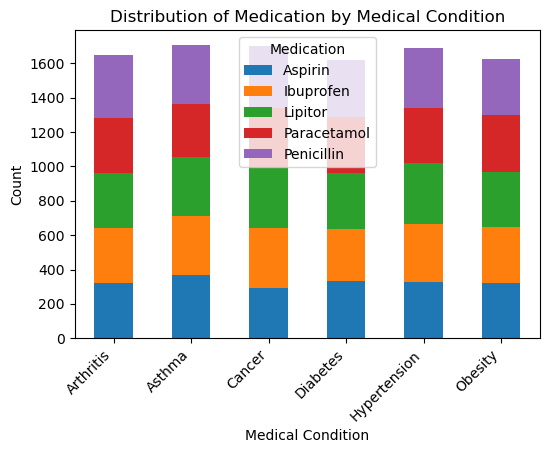

In [195]:
medication = df.groupby(['Medical Condition', 'Medication']).size().unstack()

medication.plot(kind='bar', stacked=True, figsize=(6, 4))

plt.xlabel('Medical Condition')
plt.ylabel('Count')
plt.title('Distribution of Medication by Medical Condition')

plt.xticks(rotation=45, ha='right') 

plt.show()

#According to the chart, pencillin is the most commonly used medication in all medical conditions.

Comparison of hospital visits by gender

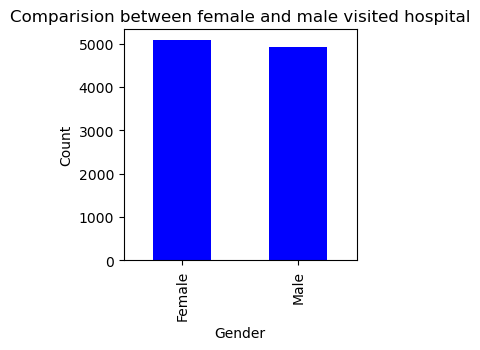

In [204]:
Gender=df['Gender'].value_counts()

Gender.plot(kind='bar',color='blue', figsize=(3,3))

plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Comparision between female and male visited hospital')

plt.show()

#More women than men are seeking medical attention in hospitals as a result of various health issues.